In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    build_elements, build_load_vector, apply_restraints,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d, plot_gmsh_mesh,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 1.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters
output_path = os.getcwd()
mesh_name = 'stress_concentrations'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Initialize GMSH
gmsh.initialize()
gmsh.model.add(output_file)

# Parameters
hb = 1000
bb = 2000
hc = 200
xc = 800

N_hb = 15
N_bb = 15
N_c = 5

# Create points
gmsh.model.geo.addPoint(0, 0, 0, tag=1)
gmsh.model.geo.addPoint(xc, 0, 0, tag=2)
gmsh.model.geo.addPoint(xc + hc, hc, 0, tag=3)
gmsh.model.geo.addPoint(xc + 2 * hc, 0, 0, tag=4)
gmsh.model.geo.addPoint(bb, 0, 0, tag=5)
gmsh.model.geo.addPoint(bb, hc, 0, tag=6)
gmsh.model.geo.addPoint(bb, hb, 0, tag=7)
gmsh.model.geo.addPoint(xc + hc, hb, 0, tag=8)
gmsh.model.geo.addPoint(0, hb, 0, tag=9)
gmsh.model.geo.addPoint(0, hc, 0, tag=10)

# Create lines
gmsh.model.geo.addLine(1, 2, tag=1)
gmsh.model.geo.addLine(2, 3, tag=2)
gmsh.model.geo.addLine(3, 4, tag=3)
gmsh.model.geo.addLine(4, 5, tag=4)
gmsh.model.geo.addLine(5, 6, tag=5)
gmsh.model.geo.addLine(6, 7, tag=6)
gmsh.model.geo.addLine(7, 8, tag=7)
gmsh.model.geo.addLine(8, 9, tag=8)
gmsh.model.geo.addLine(9, 10, tag=9)
gmsh.model.geo.addLine(10, 1, tag=10)
gmsh.model.geo.addLine(10, 3, tag=11)
gmsh.model.geo.addLine(3, 6, tag=12)
gmsh.model.geo.addLine(3, 8, tag=13)

# Create curve loops and surfaces
gmsh.model.geo.addCurveLoop([8, 9, 11, 13], 1)
gmsh.model.geo.addPlaneSurface([1], 1)

gmsh.model.geo.addCurveLoop([7, -13, 12, 6], 2)
gmsh.model.geo.addPlaneSurface([2], 2)

gmsh.model.geo.addCurveLoop([10, 1, 2, -11], 3)
gmsh.model.geo.addPlaneSurface([3], 3)

gmsh.model.geo.addCurveLoop([3, 4, 5, -12], 4)
gmsh.model.geo.addPlaneSurface([4], 4)

# Set transfinite meshing
gmsh.model.geo.mesh.setTransfiniteCurve(9, N_hb)
gmsh.model.geo.mesh.setTransfiniteCurve(13, N_hb)
gmsh.model.geo.mesh.setTransfiniteCurve(6, N_hb)

gmsh.model.geo.mesh.setTransfiniteCurve(8, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(11, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(1, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(7, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(12, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(4, N_bb)

gmsh.model.geo.mesh.setTransfiniteCurve(10, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(2, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(3, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(5, N_c)

# Set transfinite surfaces
gmsh.model.geo.mesh.setTransfiniteSurface(1, "Right", [9, 8, 3, 10])
gmsh.model.geo.mesh.setTransfiniteSurface(2, "Right", [8, 7, 6, 3])
gmsh.model.geo.mesh.setTransfiniteSurface(3, "Right", [10, 3, 2, 1])
gmsh.model.geo.mesh.setTransfiniteSurface(4, "Right", [3, 6, 5, 4])

# Synchronize before adding physical groups
gmsh.model.geo.synchronize()


def all_quads():
    # Synchronize geometry before setting meshing options
    gmsh.model.geo.synchronize()

    # Global quad mesh settings
    gmsh.option.setNumber("Mesh.RecombineAll", 1)                # Recombine all triangle meshes into quads
    gmsh.option.setNumber("Mesh.Algorithm", 8)                   # Use Delquad algorithm (for quads)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)      # Use Blossom recombination algorithm
    gmsh.option.setNumber("Mesh.Smoothing", 10)                  # Optional: improve mesh quality
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 2)


# Add physical groups
# Physical curves (boundary conditions)
gmsh.model.addPhysicalGroup(1, [9, 10], tag=101, name="Pload1")
gmsh.model.addPhysicalGroup(1, [6, 5], tag=102, name="Pload2")

# Physical points (constraints)
gmsh.model.addPhysicalGroup(0, [8], tag=110, name="Con1")
gmsh.model.addPhysicalGroup(0, [3], tag=111, name="Con2")

# Physical surface (material)
gmsh.model.addPhysicalGroup(2, [1, 2, 3, 4], tag=201, name="Steel")


201

In [6]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [7]:
# Define material
Steel = Material(name='Steel',
             E=200000.00, #Mpa
             nu=0.30,
             rho= 7850*kg/m**3*g * 1)

# Section
Beam = Membrane(name='Beam', thickness=20, material=Steel)

# Dictionaries
section_dictionary = {
    201: Beam,
}

Pload=1500*kN/m
load_dictionary = {
    101: {'value': Pload, 'direction': '-x'},
    102: {'value': Pload, 'direction': 'x'},
}

restrain_dictionary = {
    110: ['r', 'r'],
    111: ['r', 'r'],
}

In [8]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

system_nDof = mesh.system_nDof
node_map = mesh.node_map


  MESH SUMMARY

  === NODES ===  (555 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2       800.0000         0.0000         0.0000
       3      1000.0000       200.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (5 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     110      0   'Con1'
     111      0   'Con2'
     101      1   'Pload1'
     102      1   'Pload2'
     201      2   'Steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (5 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
     110      0       15          1  

In [9]:
# apply boundary conditions onto mesh.node_map
apply_restraints(mesh, restrain_dictionary)


In [10]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# build FEM elements
elements = build_elements(
    mesh               = mesh,
    node_map           = mesh.node_map,
    section_dictionary = section_dictionary,
    element_class_map  = element_map,
    load_dictionary    = load_dictionary,
    type               = 'planeStress',
    sampling_points    = 3,
    eval_points        = [0, 0],
)

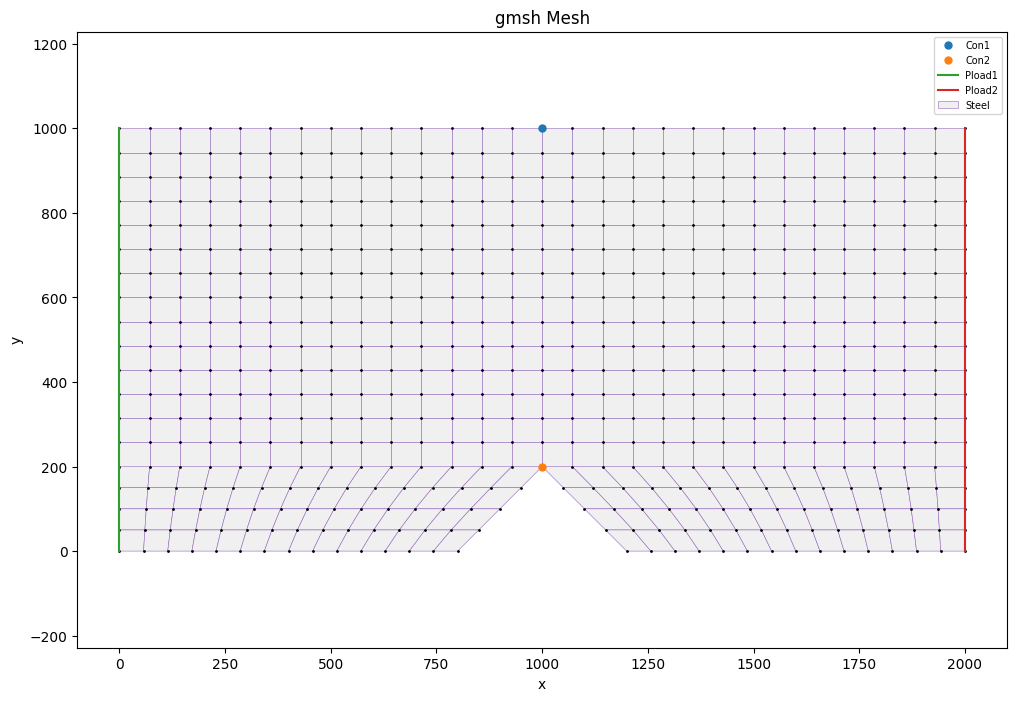

In [11]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = True,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [12]:
# Load vector
F_nodal = build_load_vector(mesh, 
                            load_dictionary)

In [13]:

F_load = np.zeros(system_nDof)

for tag, f_vec in F_nodal.items():
    if tag in mesh.node_map:
        F_load[mesh.node_map[tag].idx[:len(f_vec)]] += f_vec

for elem in elements:
    F_load[elem.idx] += elem.F_fe_body

In [14]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in node_map.values():
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [15]:
# Reactions per node
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 3:  Rx=+0.000000  Ry=-24253.452875
Node 8:  Rx=-0.000000  Ry=+27263.157008
----------------------------------------------------------------------------------------------------
Applied X:  +0.0000   Reaction X: +0.0000   Balance: 6.2651e-09
Applied Y:  -3018.7332   Reaction Y: +3009.7041   Balance: -9.0291e+00


In [16]:
for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 1 at [0. 0.]:  Fx=-37500.0000  Fy=-1.1196
Node 2 at [800.   0.]:  Fx=+0.0000  Fy=-1.1507
Node 3 at [1000.  200.]:  Fx=+0.0000  Fy=-5.8859
Node 4 at [1200.    0.]:  Fx=+0.0000  Fy=-1.1500
Node 5 at [2000.    0.]:  Fx=+37500.0000  Fy=-1.1195
Node 6 at [2000.  200.]:  Fx=+80357.1429  Fy=-2.9199
Node 7 at [2000. 1000.]:  Fx=+42857.1429  Fy=-1.5716
Node 8 at [1000. 1000.]:  Fx=+0.0000  Fy=-3.1432
Node 9 at [   0. 1000.]:  Fx=-42857.1429  Fy=-1.5716
Node 10 at [  0. 200.]:  Fx=-80357.1429  Fy=-2.9201
Node 11 at [57.142857  0.      ]:  Fx=+0.0000  Fy=-2.2391
Node 12 at [114.285714   0.      ]:  Fx=+0.0000  Fy=-2.2391
Node 13 at [171.428571   0.      ]:  Fx=+0.0000  Fy=-2.2391
Node 14 at [228.571429   0.      ]:  Fx=+0.0000  Fy=-2.2391
Node 15 at [285.714286   0.      ]:  Fx=+0.0000  Fy=-2.2391
Node 16 at [342.857143   0.      ]:  Fx=+0.0000  Fy=-2.2391
Node 17 at [400.   0.]:  Fx=+0.0000  Fy=-2.2392
Node 18 at [457.142857   0.      ]:  Fx=+0.0000  Fy=-2.2394
Node 19 at [514.285714   0.  

In [17]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [18]:

# VISUALIZE RESULTS IN GMSH


gmsh.initialize()
gmsh.open(output_file)

# Node tags already computed above
# node_tags = np.array([node.name for node in nodes_list])

# --- Nodal vector fields ---
# VectorType options:
# 1 → Line segments (simple lines)
# 2 → Arrows
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation

add_node_data_view("Displacements",
                   node_tags,
                   u_3d,
                   vector_type=5,
                   factor=5)

add_node_data_view("Applied Loads",
                   node_tags,
                   F_3d,
                   arrow_size_max=60,
                   arrow_size_min=20)

add_node_data_view("Reactions",
                   node_tags,
                   R_3d)

2

In [19]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [20]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [21]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [22]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 0])
add_node_data_view("Sxx Nodal Averaged",    
                    node_tags, sxx_nodal)

# -----------------
syy_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 1])
add_node_data_view("Syy Nodal Averaged",    
                    node_tags, syy_nodal)

# -----------------
sxy_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 2])
add_node_data_view("Sxy Nodal Averaged",    
                    node_tags, sxy_nodal)

# -----------------
s1_nodal = compute_nodal_average(   mesh, 
                                    element_tags_list, 
                                    sigma_principal_gmsh[:, 0])
add_node_data_view("Principal Stress S1 Nodal Averaged", 
                    node_tags, s1_nodal)

# -----------------
s2_nodal = compute_nodal_average(   mesh, 
                                    element_tags_list, 
                                    sigma_principal_gmsh[:, 1])
add_node_data_view("Principal Stress S2 Nodal Averaged", 
                    node_tags, s2_nodal)

# -----------------
vm_nodal = compute_nodal_average(mesh, 
                                 element_tags_list, 
                                 von_mises_gmsh)
add_node_data_view("Von Mises Nodal Averaged",
                   node_tags, vm_nodal)

# -----------------
exx_nodal = compute_nodal_average(mesh, 
                                element_tags_list, 
                                epsilon_gmsh[:, 0])
add_node_data_view("Strain Exx Averaged", 
                    node_tags, exx_nodal)

# -----------------
# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

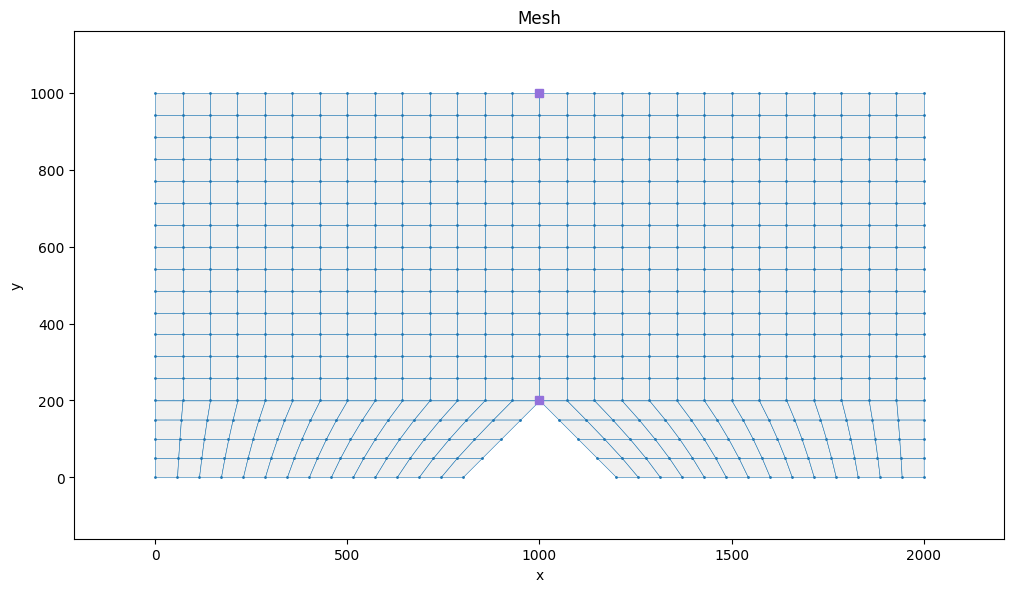

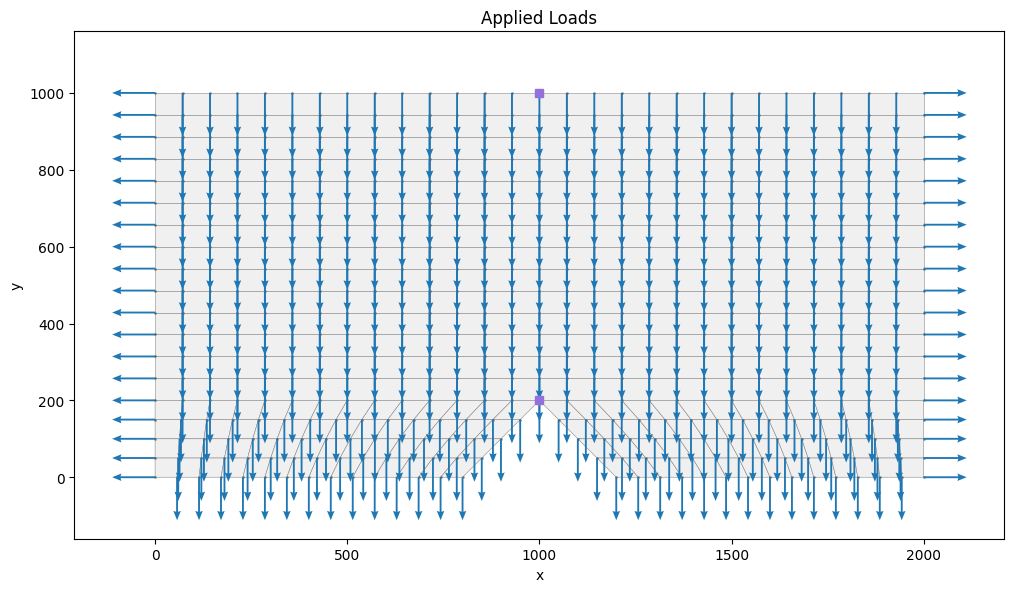

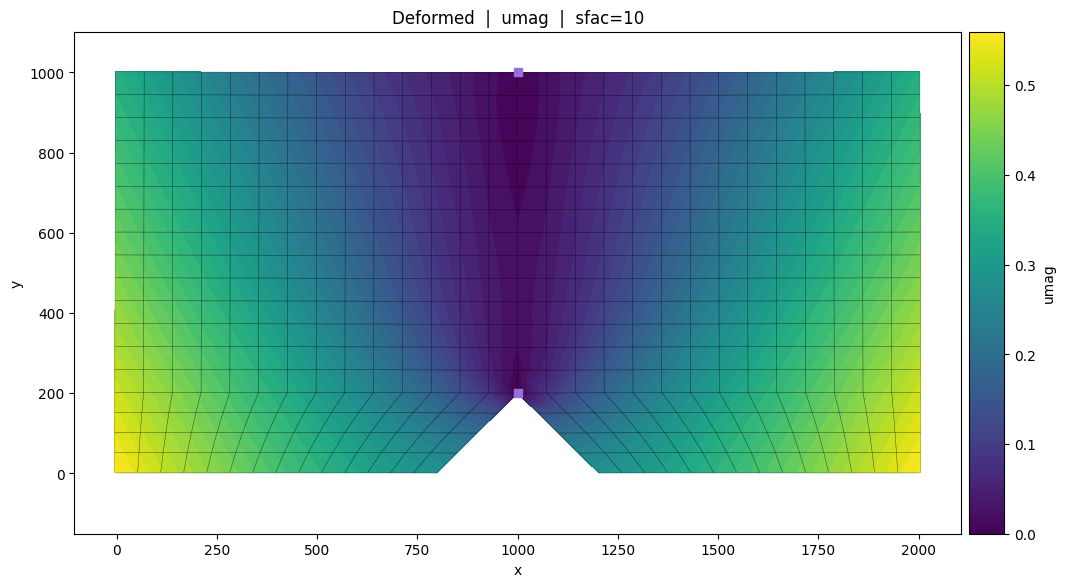

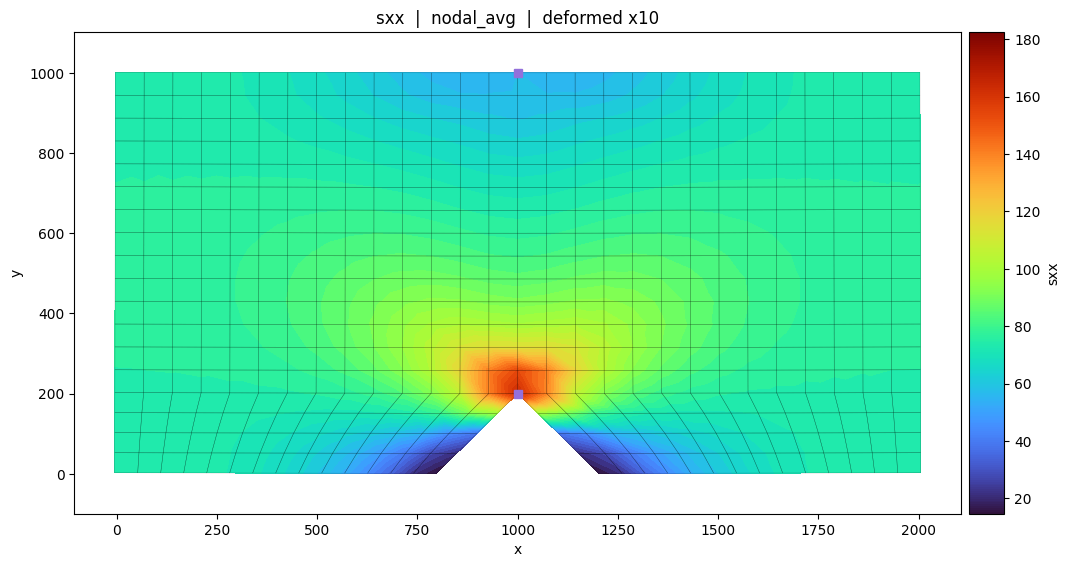

In [23]:
# Mesh
plot_mesh(
    nodes               = node_map.values(),
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Loads
plot_loads_2d(
    nodes               = node_map.values(),
    elements            = elements,
    F_load              = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Deformed
plot_deformed(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    sfac                = 10,
    cmap                = 'viridis',
    limit               = None,
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'sxx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type         = 'nodal_avg', # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 10,
    limit               = None,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)